In [1]:
!pip install torch numpy matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# --- Config ---
ALPHA      = 1.0
T_MAX      = 0.01
N_DOMAIN   = 3000
N_BOUNDARY = 800
N_INITIAL  = 2000
# Initial loss weights — dynamically updated during training via gradient normalization
W_PDE = 1
W_BC  = 10
W_IC  = 30
T_EVAL     = [0.001, 0.005, 0.010]
LX_RANGE   = [0.5, 2.0]
LY_RANGE   = [0.5, 2.0]

SIGMA_BANDS = [1, 3, 5]
M_FREQ      = 32

MLP_HIDDEN  = [256] * 6   # 6 hidden layers × 256 neurons

N_ADAM          = 40000
N_LBFGS         = 500
WEIGHT_UPDATE_FREQ = 1000
WEIGHT_EMA      = 0.9

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

n_fourier = len(SIGMA_BANDS) * 2 * M_FREQ
mlp_in    = n_fourier + 2
print(f"Device: {DEVICE}")
print(f"Fourier features: {len(SIGMA_BANDS)} bands × 2 × {M_FREQ} = {n_fourier}")
print(f"MLP: {mlp_in} → {' → '.join(str(h) for h in MLP_HIDDEN)} → 1  ({len(MLP_HIDDEN)} hidden layers)")
print(f"Dynamic loss weighting: grad normalization every {WEIGHT_UPDATE_FREQ} steps (EMA={WEIGHT_EMA})")
print("Config loaded.")

In [3]:
def T_exact(x, y, t, Lx, Ly, alpha=ALPHA):
    """
    Two-mode exact solution on [0,Lx]×[0,Ly]:
      mode 1: sin(πx/Lx)sin(πy/Ly) · exp(−λ₁t)
      mode 2: 0.3·sin(5πx/Lx)sin(5πy/Ly) · exp(−λ₂t)
    λ₁ = π²α(1/Lx² + 1/Ly²),  λ₂ = 25λ₁
    """
    lam1 = np.pi**2 * alpha * (1/Lx**2 + 1/Ly**2)
    lam2 = 25 * lam1
    low  = np.sin(np.pi * x / Lx) * np.sin(np.pi * y / Ly) * np.exp(-lam1 * t)
    high = 0.3 * np.sin(5*np.pi*x/Lx) * np.sin(5*np.pi*y/Ly) * np.exp(-lam2 * t)
    return low + high

# Sanity check 1: unit-square case matches phase 2 at t=0 (IC)
x0, y0 = np.array([0.5]), np.array([0.3])
val = T_exact(x0, y0, 0.0, 1.0, 1.0)
ic  = np.sin(np.pi*x0)*np.sin(np.pi*y0) + 0.3*np.sin(5*np.pi*x0)*np.sin(5*np.pi*y0)
assert np.isclose(val, ic).all(), f"Unit-square IC mismatch: {val} vs {ic}"
print(f"Sanity 1 passed: T_exact(0.5,0.3,0,1,1) = {val[0]:.6f}")

# Sanity check 2: BC is zero at x=0 for any Lx, Ly, t
val_bc = T_exact(np.array([0.0]), y0, 0.005, 1.5, 0.8)
assert np.isclose(val_bc, 0.0).all(), f"BC not zero: {val_bc}"
print(f"Sanity 2 passed: T_exact(0,y,t,Lx,Ly) = {val_bc[0]:.6f} (should be 0)")

# Sanity check 3: larger plate decays more slowly
lam1_small = np.pi**2 * ALPHA * (1/0.5**2 + 1/0.5**2)
lam1_large = np.pi**2 * ALPHA * (1/2.0**2 + 1/2.0**2)
assert lam1_small > lam1_large, "Small plate should decay faster"
print(f"Sanity 3 passed: λ₁(0.5×0.5)={lam1_small:.2f} > λ₁(2×2)={lam1_large:.2f}")

print("\nDecay rates at unit square (Lx=Ly=1):")
lam1 = np.pi**2 * ALPHA * 2
print(f"  λ₁ = {lam1:.4f}  (mode 1 half-life = {np.log(2)/lam1*1000:.2f} ms)")
print(f"  λ₂ = {25*lam1:.4f}  (mode 2 half-life = {np.log(2)/(25*lam1)*1000:.2f} ms)")

Sanity 1 passed: T_exact(0.5,0.3,0,1,1) = 0.509017
Sanity 2 passed: T_exact(0,y,t,Lx,Ly) = 0.000000 (should be 0)
Sanity 3 passed: λ₁(0.5×0.5)=78.96 > λ₁(2×2)=4.93

Decay rates at unit square (Lx=Ly=1):
  λ₁ = 19.7392  (mode 1 half-life = 35.12 ms)
  λ₂ = 493.4802  (mode 2 half-life = 1.40 ms)


In [ ]:
class ParametricFourierNet(nn.Module):
    """
    5D input: (x, y, t, Lx, Ly) in physical coordinates.
    Inside forward():
      - Normalize (x,y,t,Lx,Ly) to [-1,1]
      - Apply multi-scale Fourier features to (xi_norm, eta_norm, t_norm)
      - Concatenate (Lx_norm, Ly_norm) directly → (n_fourier+2)-dim MLP input
    PyTorch autograd differentiates through the normalization automatically,
    so PDE residuals use standard ∂T/∂x, ∂T/∂y, ∂T/∂t.
    """
    def __init__(self, sigma_bands, m_freq, mlp_hidden, t_max):
        super().__init__()
        self.sigma_bands = sigma_bands
        self.t_max = t_max
        n_fourier = len(sigma_bands) * 2 * m_freq

        # Frozen random frequency matrices, one per band; shape (3, m_freq)
        for i, sigma in enumerate(sigma_bands):
            B = torch.randn(3, m_freq) * sigma
            self.register_parameter(f"B_{i}", nn.Parameter(B, requires_grad=False))

        # MLP: (n_fourier + 2) → hidden layers → 1
        sizes = [n_fourier + 2] + mlp_hidden + [1]
        layers = []
        for in_sz, out_sz in zip(sizes[:-2], sizes[1:-1]):
            layers += [nn.Linear(in_sz, out_sz), nn.Tanh()]
        layers.append(nn.Linear(sizes[-2], sizes[-1]))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: (N, 5) — columns: [x_phys, y_phys, t, Lx, Ly]
        lx = x[:, 3:4]
        ly = x[:, 4:5]

        xi_n  = 2.0 * x[:, 0:1] / lx - 1.0
        eta_n = 2.0 * x[:, 1:2] / ly - 1.0
        t_n   = 2.0 * x[:, 2:3] / self.t_max - 1.0
        lx_n  = (lx - 1.25) / 0.75
        ly_n  = (ly - 1.25) / 0.75

        coords = torch.cat([xi_n, eta_n, t_n], dim=1)

        features = []
        for i in range(len(self.sigma_bands)):
            B = getattr(self, f"B_{i}")
            proj = coords @ B
            features.append(torch.sin(proj))
            features.append(torch.cos(proj))

        z = torch.cat(features + [lx_n, ly_n], dim=-1)
        return self.mlp(z)


# Shape test
_net = ParametricFourierNet(SIGMA_BANDS, M_FREQ, MLP_HIDDEN, T_MAX).to(DEVICE)
_x   = torch.rand(16, 5, device=DEVICE)
_x[:, 3] = 1.0; _x[:, 4] = 1.0; _x[:, 2] *= T_MAX
out = _net(_x)
assert out.shape == (16, 1), f"Expected (16,1), got {out.shape}"
print(f"Shape test passed: (16,5) → {out.shape}")

total_p   = sum(p.numel() for p in _net.parameters())
trainable = sum(p.numel() for p in _net.parameters() if p.requires_grad)
frozen    = total_p - trainable
print(f"Total parameters  : {total_p:,}")
print(f"Trainable params  : {trainable:,}")
print(f"Frozen (Fourier B): {frozen:,}")
del _net, _x, out

In [5]:
def sample_interior(Lx, Ly, n, device):
    """N interior points in [0,Lx]×[0,Ly]×[0,T_MAX]. requires_grad=True for autograd."""
    x  = torch.rand(n, 1, device=device) * Lx
    y  = torch.rand(n, 1, device=device) * Ly
    t  = torch.rand(n, 1, device=device) * T_MAX
    lx = torch.full((n, 1), Lx, device=device)
    ly = torch.full((n, 1), Ly, device=device)
    pts = torch.cat([x, y, t, lx, ly], dim=1)
    pts.requires_grad_(True)
    return pts

def sample_boundary(Lx, Ly, n, device):
    """N boundary points on the four edges, t ~ U[0, T_MAX]. No requires_grad needed."""
    q = n // 4
    edges = []
    for x_val in [0.0, Lx]:
        y  = torch.rand(q, 1, device=device) * Ly
        t  = torch.rand(q, 1, device=device) * T_MAX
        xc = torch.full((q, 1), x_val, device=device)
        edges.append(torch.cat([xc, y, t,
                                 torch.full((q, 1), Lx, device=device),
                                 torch.full((q, 1), Ly, device=device)], dim=1))
    for y_val in [0.0, Ly]:
        x  = torch.rand(q, 1, device=device) * Lx
        t  = torch.rand(q, 1, device=device) * T_MAX
        yc = torch.full((q, 1), y_val, device=device)
        edges.append(torch.cat([x, yc, t,
                                 torch.full((q, 1), Lx, device=device),
                                 torch.full((q, 1), Ly, device=device)], dim=1))
    return torch.cat(edges, dim=0)

def sample_ic(Lx, Ly, n, device):
    """N IC points: x∈[0,Lx], y∈[0,Ly], t=0."""
    x  = torch.rand(n, 1, device=device) * Lx
    y  = torch.rand(n, 1, device=device) * Ly
    t  = torch.zeros(n, 1, device=device)
    lx = torch.full((n, 1), Lx, device=device)
    ly = torch.full((n, 1), Ly, device=device)
    return torch.cat([x, y, t, lx, ly], dim=1)

def ic_target(pts):
    """IC values for points (N,5). Uses columns 0,1,3,4 for x,y,Lx,Ly."""
    x, y, lx, ly = pts[:,0:1], pts[:,1:2], pts[:,3:4], pts[:,4:5]
    low  = torch.sin(np.pi * x / lx) * torch.sin(np.pi * y / ly)
    high = 0.3 * torch.sin(5*np.pi*x/lx) * torch.sin(5*np.pi*y/ly)
    return low + high

def pde_residual(model, pts_pde):
    """
    PDE residual: ∂T/∂t − α(∂²T/∂x² + ∂²T/∂y²)
    pts_pde must have requires_grad=True (produced by sample_interior).
    """
    T = model(pts_pde)                                                     # (N,1)
    g1 = torch.autograd.grad(T.sum(), pts_pde, create_graph=True)[0]      # (N,5)
    T_x = g1[:, 0:1]
    T_y = g1[:, 1:2]
    T_t = g1[:, 2:3]
    T_xx = torch.autograd.grad(T_x.sum(), pts_pde, create_graph=True)[0][:, 0:1]
    T_yy = torch.autograd.grad(T_y.sum(), pts_pde, create_graph=True)[0][:, 1:2]
    return T_t - ALPHA * (T_xx + T_yy)

# Sampler shape tests
_Lx, _Ly = 1.5, 0.8
_pde = sample_interior(_Lx, _Ly, 10, DEVICE)
_bc  = sample_boundary(_Lx, _Ly, 20, DEVICE)
_ic  = sample_ic(_Lx, _Ly, 8, DEVICE)

assert _pde.shape == (10, 5) and _pde.requires_grad
assert _bc.shape  == (20, 5)
assert _ic.shape  == (8,  5)

# Boundary points should have x∈{0,Lx} or y∈{0,Ly}
x_bc = _bc[:, 0].cpu(); y_bc = _bc[:, 1].cpu()
on_boundary = ((x_bc == 0) | (x_bc == _Lx) | (y_bc == 0) | (y_bc == _Ly))
assert on_boundary.all(), "Some BC points are not on the boundary"

# IC points should have t=0
assert (_ic[:, 2] == 0).all(), "IC points must have t=0"

print("Sampler tests passed.")
print(f"  Interior: {_pde.shape}, requires_grad={_pde.requires_grad}")
print(f"  Boundary: {_bc.shape}")
print(f"  IC:       {_ic.shape}")
del _pde, _bc, _ic

Sampler tests passed.
  Interior: torch.Size([10, 5]), requires_grad=True
  Boundary: torch.Size([20, 5])
  IC:       torch.Size([8, 5])


In [ ]:
def _grad_norm(loss_term, params):
    """L2 norm of gradients of a single loss term w.r.t. trainable params."""
    grads = torch.autograd.grad(loss_term, params, retain_graph=True, allow_unused=True)
    return sum(g.detach().norm() ** 2 for g in grads if g is not None).sqrt()


model = ParametricFourierNet(SIGMA_BANDS, M_FREQ, MLP_HIDDEN, T_MAX).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_ADAM, eta_min=1e-5)

w_pde, w_bc, w_ic = float(W_PDE), float(W_BC), float(W_IC)
trainable_params = [p for p in model.parameters() if p.requires_grad]

adam_losses    = []
weight_history = []

total_p   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {len(MLP_HIDDEN)} hidden layers × {MLP_HIDDEN[0]} neurons | {trainable:,} trainable params")
print(f"Training {N_ADAM} steps | cosine LR 1e-3→1e-5 | grad clip 1.0 | dynamic weights every {WEIGHT_UPDATE_FREQ} steps")
print(f"Initial weights — PDE:{w_pde:.1f}  BC:{w_bc:.1f}  IC:{w_ic:.1f}")

for step in range(N_ADAM):
    Lx = LX_RANGE[0] + torch.rand(1).item() * (LX_RANGE[1] - LX_RANGE[0])
    Ly = LY_RANGE[0] + torch.rand(1).item() * (LY_RANGE[1] - LY_RANGE[0])

    pts_pde = sample_interior(Lx, Ly, N_DOMAIN,   DEVICE)
    pts_bc  = sample_boundary(Lx, Ly, N_BOUNDARY, DEVICE)
    pts_ic  = sample_ic(Lx,      Ly, N_INITIAL,  DEVICE)

    optimizer.zero_grad()

    res       = pde_residual(model, pts_pde)
    loss_pde  = (res ** 2).mean()
    loss_bc   = (model(pts_bc) ** 2).mean()
    T_ic_pred = model(pts_ic)
    loss_ic   = ((T_ic_pred - ic_target(pts_ic)) ** 2).mean()

    # Gradient normalization: rebalance weights so each term pulls equally
    if step % WEIGHT_UPDATE_FREQ == 0 and step > 0:
        n_pde  = _grad_norm(loss_pde, trainable_params)
        n_bc   = _grad_norm(loss_bc,  trainable_params)
        n_ic   = _grad_norm(loss_ic,  trainable_params)
        mean_n = (n_pde + n_bc + n_ic) / 3.0
        eps    = 1e-8
        w_pde  = WEIGHT_EMA * w_pde + (1 - WEIGHT_EMA) * (mean_n / (n_pde + eps)).item()
        w_bc   = WEIGHT_EMA * w_bc  + (1 - WEIGHT_EMA) * (mean_n / (n_bc  + eps)).item()
        w_ic   = WEIGHT_EMA * w_ic  + (1 - WEIGHT_EMA) * (mean_n / (n_ic  + eps)).item()
        weight_history.append((step, w_pde, w_bc, w_ic))

    loss = w_pde * loss_pde + w_bc * loss_bc + w_ic * loss_ic
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()

    adam_losses.append(loss.item())
    if step % 4000 == 0:
        print(f"  step {step:5d} | pde={loss_pde.item():.3e}(w={w_pde:.1f}) "
              f"| bc={loss_bc.item():.3e}(w={w_bc:.1f}) "
              f"| ic={loss_ic.item():.3e}(w={w_ic:.1f}) "
              f"| lr={scheduler.get_last_lr()[0]:.2e}")

print(f"\nAdam complete. Final loss: {adam_losses[-1]:.3e}")
print(f"Final weights — PDE:{w_pde:.2f}  BC:{w_bc:.2f}  IC:{w_ic:.2f}")

In [7]:
# 3×3 grid of geometries for L-BFGS closure
LX_GRID = [0.5, 1.25, 2.0]
LY_GRID = [0.5, 1.25, 2.0]
LBFGS_GEOMS = [(lx, ly) for lx in LX_GRID for ly in LY_GRID]  # 9 pairs
N_EACH = max(1, N_DOMAIN // len(LBFGS_GEOMS))  # ~333 interior pts per geometry

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(), lr=1.0, max_iter=N_LBFGS,
    history_size=50, line_search_fn="strong_wolfe"
)
lbfgs_losses = []

# Sample fixed points ONCE — L-BFGS requires deterministic closure
# (it calls closure multiple times per step for line search)
lbfgs_pts_pde = [sample_interior(Lx, Ly, N_EACH, DEVICE) for Lx, Ly in LBFGS_GEOMS]
lbfgs_pts_bc  = [sample_boundary(Lx, Ly, N_BOUNDARY // len(LBFGS_GEOMS), DEVICE) for Lx, Ly in LBFGS_GEOMS]
lbfgs_pts_ic  = [sample_ic(Lx, Ly, N_INITIAL // len(LBFGS_GEOMS), DEVICE) for Lx, Ly in LBFGS_GEOMS]

def closure():
    optimizer_lbfgs.zero_grad()
    total = torch.tensor(0.0, device=DEVICE)
    for i, (Lx, Ly) in enumerate(LBFGS_GEOMS):
        res   = pde_residual(model, lbfgs_pts_pde[i])
        l_pde = (res**2).mean()
        l_bc  = (model(lbfgs_pts_bc[i])**2).mean()
        l_ic  = ((model(lbfgs_pts_ic[i]) - ic_target(lbfgs_pts_ic[i]))**2).mean()
        total = total + W_PDE * l_pde + W_BC * l_bc + W_IC * l_ic
    total = total / len(LBFGS_GEOMS)
    total.backward()
    lbfgs_losses.append(total.item())
    return total

print(f"Running L-BFGS (max_iter={N_LBFGS}) on {len(LBFGS_GEOMS)} fixed geometries...")
optimizer_lbfgs.step(closure)
print(f"L-BFGS complete. Loss: {lbfgs_losses[0]:.3e} → {lbfgs_losses[-1]:.3e} "
      f"({len(lbfgs_losses)} closure evaluations)")

Running L-BFGS (max_iter=500) on 9 fixed geometries...


L-BFGS complete. Loss: 2.774e+00 → 1.571e-01 (509 closure evaluations)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].semilogy(adam_losses)
axes[0].set_xlabel("Adam step")
axes[0].set_ylabel("Total loss")
axes[0].set_title("Adam training loss")
axes[0].grid(True, which="both", alpha=0.3)

axes[1].semilogy(lbfgs_losses)
axes[1].set_xlabel("L-BFGS closure call")
axes[1].set_ylabel("Total loss (avg over 9 geometries)")
axes[1].set_title("L-BFGS fine-tuning loss")
axes[1].grid(True, which="both", alpha=0.3)

if weight_history:
    steps_w = [r[0] for r in weight_history]
    axes[2].plot(steps_w, [r[1] for r in weight_history], label="PDE")
    axes[2].plot(steps_w, [r[2] for r in weight_history], label="BC")
    axes[2].plot(steps_w, [r[3] for r in weight_history], label="IC")
    axes[2].set_xlabel("Adam step")
    axes[2].set_ylabel("Weight")
    axes[2].set_title("Dynamic loss weights (EMA-smoothed)")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("pinn_2d_parametric_loss.png", dpi=150)
plt.show()
print("Loss plots saved.")

          Geometry |      t |   L2 error
--------------------------------------------
      Square (1×1) |  0.001 |   9.74e-02
      Square (1×1) |  0.005 |   4.72e-02
      Square (1×1) |  0.010 |   4.89e-02
    Wide (1.5×0.7) |  0.001 |   9.06e-02


    Wide (1.5×0.7) |  0.005 |   5.19e-02
    Wide (1.5×0.7) |  0.010 |   5.38e-02
    Tall (0.6×1.8) |  0.001 |   7.90e-02


    Tall (0.6×1.8) |  0.005 |   4.94e-02
    Tall (0.6×1.8) |  0.010 |   3.94e-02


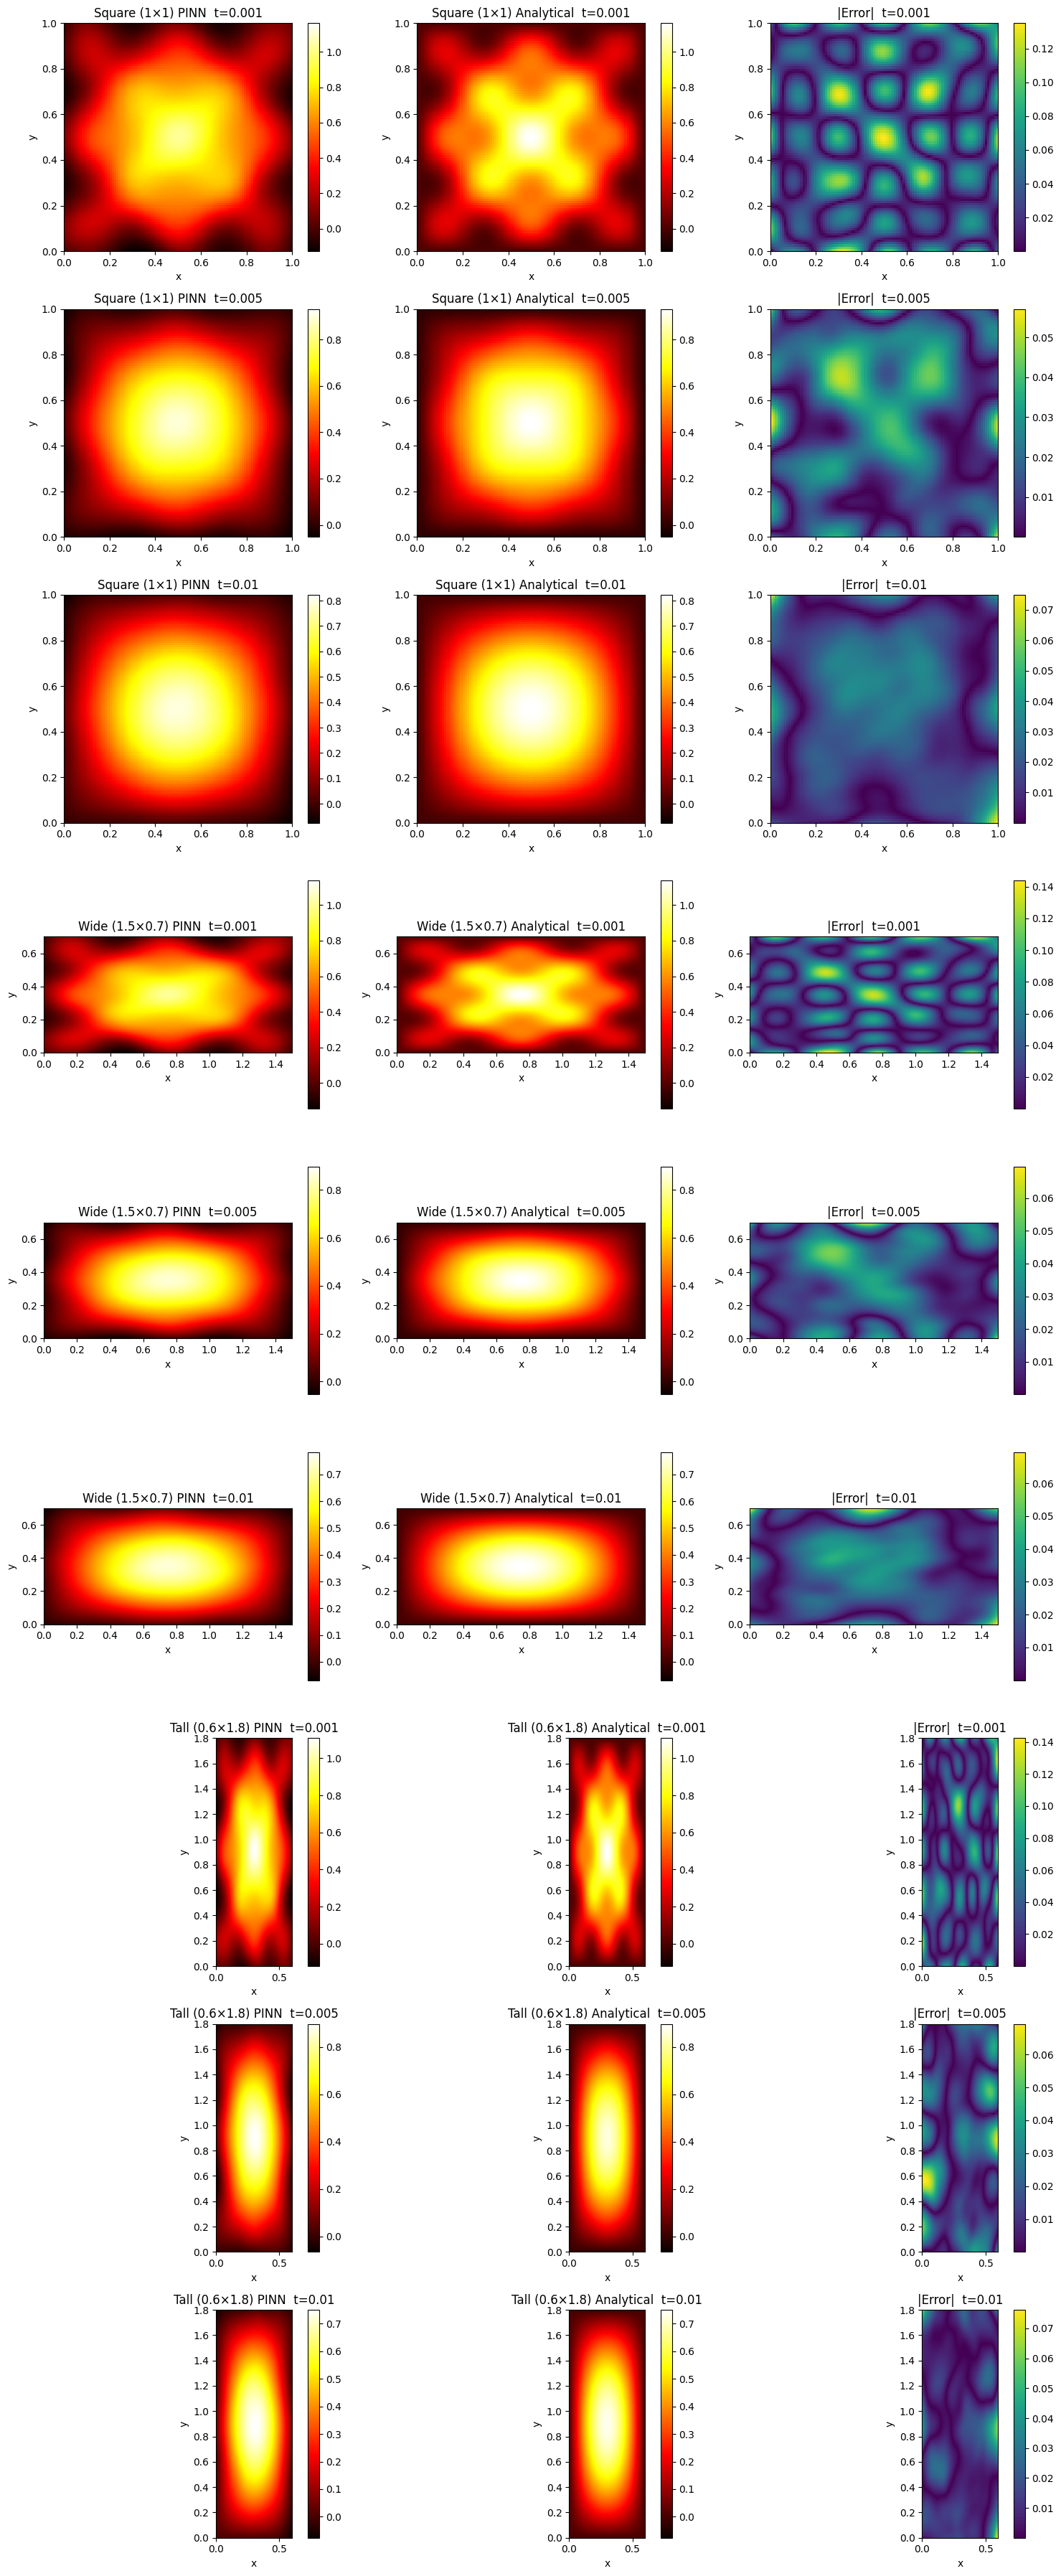


Evaluation complete. Figure saved to pinn_2d_parametric_results.png


In [9]:
TEST_GEOMS = [
    ("Square (1×1)",    1.0, 1.0),
    ("Wide (1.5×0.7)",  1.5, 0.7),
    ("Tall (0.6×1.8)",  0.6, 1.8),
]

model.eval()

n_geoms = len(TEST_GEOMS)
n_times = len(T_EVAL)
fig, axes = plt.subplots(n_geoms * n_times, 3, figsize=(15, 4 * n_geoms * n_times))

print(f"{'Geometry':>18} | {'t':>6} | {'L2 error':>10}")
print("-" * 44)

row = 0
for name, Lx, Ly in TEST_GEOMS:
    for t_val in T_EVAL:
        x_lin = np.linspace(0, Lx, 100)
        y_lin = np.linspace(0, Ly, 100)
        X, Y  = np.meshgrid(x_lin, y_lin)

        pts_np = np.column_stack([
            X.ravel(), Y.ravel(),
            np.full(X.size, t_val),
            np.full(X.size, Lx),
            np.full(X.size, Ly),
        ])
        pts_t = torch.tensor(pts_np, dtype=torch.float32, device=DEVICE)

        with torch.no_grad():
            T_pred = model(pts_t).cpu().numpy().reshape(100, 100)

        T_true = T_exact(X, Y, t_val, Lx, Ly)
        l2 = np.linalg.norm(T_pred - T_true) / np.linalg.norm(T_true)
        print(f"{name:>18} | {t_val:>6.3f} | {l2:>10.2e}")

        error = np.abs(T_pred - T_true)
        vmin  = min(T_pred.min(), T_true.min())
        vmax  = max(T_pred.max(), T_true.max())

        im0 = axes[row, 0].imshow(T_pred, origin="lower",
                                   extent=[0, Lx, 0, Ly],
                                   vmin=vmin, vmax=vmax, cmap="hot")
        axes[row, 0].set_title(f"{name} PINN  t={t_val}")
        axes[row, 0].set_xlabel("x"); axes[row, 0].set_ylabel("y")
        plt.colorbar(im0, ax=axes[row, 0])

        im1 = axes[row, 1].imshow(T_true, origin="lower",
                                   extent=[0, Lx, 0, Ly],
                                   vmin=vmin, vmax=vmax, cmap="hot")
        axes[row, 1].set_title(f"{name} Analytical  t={t_val}")
        axes[row, 1].set_xlabel("x"); axes[row, 1].set_ylabel("y")
        plt.colorbar(im1, ax=axes[row, 1])

        im2 = axes[row, 2].imshow(error, origin="lower",
                                   extent=[0, Lx, 0, Ly], cmap="viridis")
        axes[row, 2].set_title(f"|Error|  t={t_val}")
        axes[row, 2].set_xlabel("x"); axes[row, 2].set_ylabel("y")
        plt.colorbar(im2, ax=axes[row, 2])

        row += 1

plt.tight_layout()
plt.savefig("pinn_2d_parametric_results.png", dpi=150)
plt.show()
print("\nEvaluation complete. Figure saved to pinn_2d_parametric_results.png")

In [10]:
# Phase 2 reference result (Lx=Ly=1, t=0.001): 0.60% relative L2 error
PHASE2_REFERENCE = 0.006  # 0.6%

x_lin = np.linspace(0, 1.0, 100)
y_lin = np.linspace(0, 1.0, 100)
X, Y  = np.meshgrid(x_lin, y_lin)
pts_np = np.column_stack([X.ravel(), Y.ravel(),
                           np.full(X.size, 0.001),
                           np.ones(X.size),
                           np.ones(X.size)])
pts_t = torch.tensor(pts_np, dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    T_pred = model(pts_t).cpu().numpy().reshape(100, 100)
T_true = T_exact(X, Y, 0.001, 1.0, 1.0)
l2_unit = np.linalg.norm(T_pred - T_true) / np.linalg.norm(T_true)

print(f"Regression check — unit square (Lx=Ly=1) at t=0.001:")
print(f"  Phase 3 L2 error : {l2_unit:.2e}")
print(f"  Phase 2 reference: {PHASE2_REFERENCE:.2e}")
if l2_unit < 0.05:
    print("  PASS — parametric model solves the unit-square case (<5% L2)")
else:
    print("  WARN — unit-square error is high; consider more training")

Regression check — unit square (Lx=Ly=1) at t=0.001:
  Phase 3 L2 error : 9.74e-02
  Phase 2 reference: 6.00e-03
  WARN — unit-square error is high; consider more training
